### Full pipeline execution code¶
- Milvus can search only one vector field at a time — either the image embedding field or the text embedding field.
- As a result, when providing only an image or text input, the retrieved items may have high visual similarity but are not actually semantically similar products.
- Example: when presenting a lotion image, the system may return a perfume image.
- To address this issue, both image and text information should be considered simultaneously to retrieve genuinely similar products.

In [47]:
#!pip install -r requirements.txt --upgrade

- create search engine

In [1]:
from embedding.search_engine import CLIPSearchEngine
from embedding.explainer import GPT4oExplainer

engine = CLIPSearchEngine(collection_name="image_collection_multimodal")
explainer = GPT4oExplainer(model_name="gpt-4o")

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


- re_rank

In [19]:
def rerank_results(results_img, results_txt, alpha=0.6):
    combined = {}

    for r in results_img:
        path = r["filepath"]
        combined[path] = {
            "label": r["label"],
            "filepath": r["filepath"],
            "score_img": r["score"],
            "score_txt": None
        }

    for r in results_txt:
        path = r["filepath"]
        if path in combined:
            combined[path]["score_txt"] = r["score"]
        else:
            combined[path] = {
                "label": r["label"],
                "filepath": r["filepath"], 
                "score_img": None,
                "score_txt": r["score"]
            }

    for v in combined.values():
        s_img = v["score_img"] if v["score_img"] is not None else 1.0
        s_txt = v["score_txt"] if v["score_txt"] is not None else 1.0
        v["score_final"] = alpha * s_img + (1 - alpha) * s_txt

    ranked = sorted(combined.values(), key=lambda x: x["score_final"])
    return ranked


- 이미지 + 텍스트 -> 이미지 & 텍스트 검색 -> rerank
- milvus의 이미지 경로와 같은 경로의 이미지를 디렉토리에서 불러옴

In [5]:
from pymilvus import MilvusClient, DataType

client = MilvusClient(uri="http://localhost:19530")
collection_name = "image_collection_multimodal"

In [43]:
query_image_path = "./images_folder/train/mixing_bowl/n03775546_1526.JPEG"
text_query = "mixing_bowl"

results_img = engine.search_by_image(query_image_path, limit=10)
results_txt = engine.search_by_text(text_query, limit=10)

final_results = rerank_results(results_img, results_txt, alpha=0.6)
final_results_wrapped = [[{"entity": r} for r in final_results]]

In [23]:
print(final_results_wrapped)

[[{'entity': {'label': 'mixing_bowl', 'filepath': './images_folder/train/mixing_bowl/n03775546_8533.JPEG', 'score_img': None, 'score_txt': 88.9380111694336, 'score_final': 36.17520446777344}}, {'entity': {'label': 'mixing_bowl', 'filepath': './images_folder/train/mixing_bowl/n03775546_18805.JPEG', 'score_img': None, 'score_txt': 88.9380111694336, 'score_final': 36.17520446777344}}, {'entity': {'label': 'mixing_bowl', 'filepath': './images_folder/train/mixing_bowl/n03775546_14407.JPEG', 'score_img': None, 'score_txt': 88.9380111694336, 'score_final': 36.17520446777344}}, {'entity': {'label': 'mixing_bowl', 'filepath': './images_folder/train/mixing_bowl/n03775546_8809.JPEG', 'score_img': None, 'score_txt': 88.9380111694336, 'score_final': 36.17520446777344}}, {'entity': {'label': 'mixing_bowl', 'filepath': './images_folder/train/mixing_bowl/n03775546_6620.JPEG', 'score_img': None, 'score_txt': 88.9380111694336, 'score_final': 36.17520446777344}}, {'entity': {'label': 'mixing_bowl', 'file


=== GPT-4o Explanation ===

The query image and the retrieved images share similarities related to mixing bowls. Here’s an explanation of their similarities:

1. **Functionality**: 
   - All images depict objects used as mixing bowls, which are essential kitchen tools for combining ingredients.

2. **Shape**:
   - The rounded, open-top shape is common across all images, designed for ease of access and mixing.

3. **Material**:
   - While the query image shows a bowl with dough in it, indicating practical use, the other images show bowls made of various materials like ceramic and glass, showcasing different designs and uses.

4. **Design and Texture**:
   - The retrieved images display decorative designs on the bowls, such as patterns or illustrations, indicative of aesthetic variety, while the query image bowl is more utilitarian.

These elements contribute to their categorization under the label "mixing bowl."

=== Retrieved Images (Top 3) ===



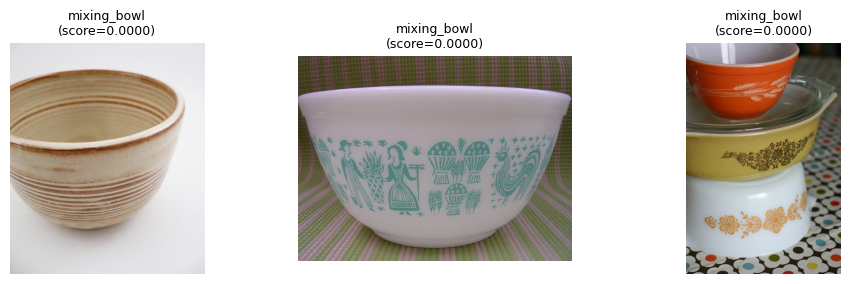

'The query image and the retrieved images share similarities related to mixing bowls. Here’s an explanation of their similarities:\n\n1. **Functionality**: \n   - All images depict objects used as mixing bowls, which are essential kitchen tools for combining ingredients.\n\n2. **Shape**:\n   - The rounded, open-top shape is common across all images, designed for ease of access and mixing.\n\n3. **Material**:\n   - While the query image shows a bowl with dough in it, indicating practical use, the other images show bowls made of various materials like ceramic and glass, showcasing different designs and uses.\n\n4. **Design and Texture**:\n   - The retrieved images display decorative designs on the bowls, such as patterns or illustrations, indicative of aesthetic variety, while the query image bowl is more utilitarian.\n\nThese elements contribute to their categorization under the label "mixing bowl."'

In [45]:
explainer.explain_with_image_query(query_image_path, final_results_wrapped)

- alpha값 조정하여 텍스트 가중치 높임

In [39]:
query_image_path = "./images_folder/train/mixing_bowl/n03775546_1526.JPEG"
text_query = "mixing_bowl"

results_img = engine.search_by_image(query_image_path, limit=10)
results_txt = engine.search_by_text(text_query, limit=10)

final_results = rerank_results(results_img, results_txt, alpha=0.2)
final_results_wrapped = [[{"entity": r} for r in final_results]]


=== GPT-4o Explanation ===

The query image shows a bowl of dough, likely used for baking or cooking. Here are the similarities between the query image and the retrieved images:

1. **First Image (Pizza)**:
   - Similarity: The dough in the query image is a primary ingredient in pizza making, as pizza requires dough as its base. Both images involve baking and preparation of a carbohydrate-based dish.

2. **Second Image (Meat Loaf)**:
   - Similarity: Both images involve food that is generally prepared in an oven. The texture of the loaf's surface can resemble baked dough, linking them through the cooking process.

3. **Third Image (Banana)**:
   - Less direct similarity, but both dough and bananas may be part of a baking process (e.g., banana bread) or part of a broader context involving homemade food preparation.

Overall, the similarities are mostly related to the process of baking and cooking, where dough is a key component in creating various dishes.

=== Retrieved Images (Top 3) 

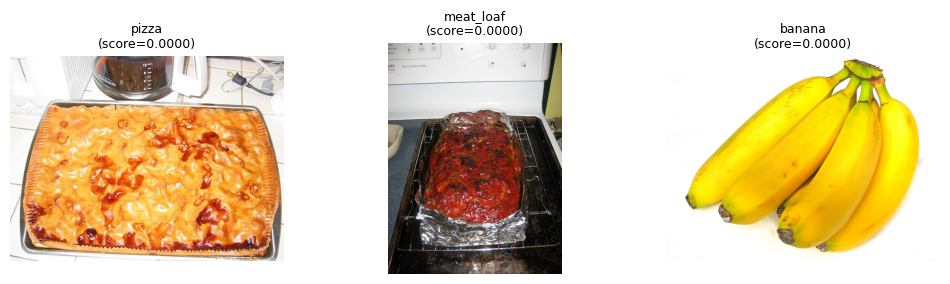

"The query image shows a bowl of dough, likely used for baking or cooking. Here are the similarities between the query image and the retrieved images:\n\n1. **First Image (Pizza)**:\n   - Similarity: The dough in the query image is a primary ingredient in pizza making, as pizza requires dough as its base. Both images involve baking and preparation of a carbohydrate-based dish.\n\n2. **Second Image (Meat Loaf)**:\n   - Similarity: Both images involve food that is generally prepared in an oven. The texture of the loaf's surface can resemble baked dough, linking them through the cooking process.\n\n3. **Third Image (Banana)**:\n   - Less direct similarity, but both dough and bananas may be part of a baking process (e.g., banana bread) or part of a broader context involving homemade food preparation.\n\nOverall, the similarities are mostly related to the process of baking and cooking, where dough is a key component in creating various dishes."

In [41]:
explainer.explain_with_image_query(query_image_path, final_results_wrapped)

---